#### **Part B – Practical (Python Programming)**

**Data Generation**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

n_samples = 5000

# Generating dummy data
student_ids = np.arange(1001, 1001 + n_samples)
ages = np.random.randint(18, 25, size=n_samples)
hours_studied = np.round(np.random.uniform(1, 12, size=n_samples), 1)

# Scores generated using normal distribution
math_scores = np.clip(
    np.random.normal(loc=65, scale=15, size=n_samples), 0, 100
).round(1)
science_scores = np.clip(
    np.random.normal(loc=60, scale=18, size=n_samples), 0, 100
).round(1)
english_scores = np.clip(
    np.random.normal(loc=70, scale=12, size=n_samples), 0, 100
).round(1)

# Pass_Fail rule: Based on average score and hours studied
avg_score = (math_scores + science_scores + english_scores) / 3
pass_prob = 1 / (1 + np.exp(-(0.05 * avg_score + 0.3 * hours_studied - 5)))
pass_fail = np.random.binomial(1, pass_prob)

# Create DataFrame
df = pd.DataFrame({
    'Student_ID': student_ids,
    'Age': ages,
    'Math_Score': math_scores,
    'Science_Score': science_scores,
    'English_Score': english_scores,
    'Hours_Studied': hours_studied,
    'Pass_Fail': pass_fail,
})

# Save to CSV
df.to_csv('students_scores.csv', index=False)
print('students_scores.csv successfully created with 5000 records!')

students_scores.csv successfully created with 5000 records!


**Step 1: Measures of Central Tendency & Dispersion**
* Calculate **mean, median, mode** of `Math_Score`.
* Find **range, variance, standard deviation** of `Science_Score`.

In [4]:
df = pd.read_csv('students_scores.csv')

# ==========================================
# Step 1: Measures of Central Tendency & Dispersion
# ==========================================
print("--- Step 1: Central Tendency & Dispersion ---")

# Mean, Median, Mode of Math_Score
math_mean = df['Math_Score'].mean()
math_median = df['Math_Score'].median()
math_mode = df['Math_Score'].mode()[0]

print(f"Math_Score - Mean: {math_mean:.2f}, Median: {math_median:.2f}, Mode: {math_mode:.2f}")

# Range, Variance, Standard Deviation of Science_Score
science_range = df['Science_Score'].max() - df['Science_Score'].min()
science_var = df['Science_Score'].var()
science_std = df['Science_Score'].std()

print(f"Science_Score - Range: {science_range:.2f}, Variance: {science_var:.2f}, Std Dev: {science_std:.2f}")




--- Step 1: Central Tendency & Dispersion ---
Math_Score - Mean: 64.79, Median: 64.90, Mode: 100.00
Science_Score - Range: 97.60, Variance: 304.06, Std Dev: 17.44


**Step 2: Probability Basics**
* Find the probability of students passing (`Pass_Fail = 1`).
* Create a **contingency table** between `Pass_Fail` and `Hours_Studied > 5`.
* Calculate **conditional probability**: $P(\text{Pass} \mid \text{Hours\_Studied} > 5)$.

In [5]:
# ==========================================
# Step 2: Probability Basics
# ==========================================
print("\n--- Step 2: Probability Basics ---")

# 1. Probability of students passing (Pass_Fail = 1)
p_pass = (df['Pass_Fail'] == 1).mean()
print(f"P(Pass_Fail = 1): {p_pass:.4f} ({p_pass * 100:.2f}%)")

# 2. Contingency table between Pass_Fail and Hours_Studied > 5
df['Hours_GT_5'] = df['Hours_Studied'] > 5
contingency_table = pd.crosstab(df['Pass_Fail'], df['Hours_GT_5'], margins=True)
print("\nContingency Table (Pass_Fail vs Hours_Studied > 5):")
print(contingency_table)

# 3. Conditional probability: P(Pass | Hours_Studied > 5)
hours_gt_5_df = df[df['Hours_GT_5'] == True]
p_pass_given_hours = (hours_gt_5_df['Pass_Fail'] == 1).mean()
print(f"\nP(Pass | Hours_Studied > 5): {p_pass_given_hours:.4f} ({p_pass_given_hours * 100:.2f}%)")





--- Step 2: Probability Basics ---
P(Pass_Fail = 1): 0.5360 (53.60%)

Contingency Table (Pass_Fail vs Hours_Studied > 5):
Hours_GT_5  False  True   All
Pass_Fail                    
0            1251  1069  2320
1             589  2091  2680
All          1840  3160  5000

P(Pass | Hours_Studied > 5): 0.6617 (66.17%)


**Step 3: Distribution & Visualization**
* Plot a **Histogram & Normal curve** for `Math_Score`.
* Calculate **Skewness & Kurtosis** for `Science_Score`.
* Perform a **Q-Q Plot** for `English_Score`.

<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\dell\AppData\Local\Temp\ipykernel_4056\2443438431.py:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.plot(x, p, 'r-', linewidth=2, label=f'Normal Curve ($\mu={mu:.1f}, \sigma={std:.1f}$)')
C:\Users\dell\AppData\Local\Temp\ipykernel_4056\2443438431.py:15: SyntaxWarni


--- Step 3: Distribution & Visualization ---


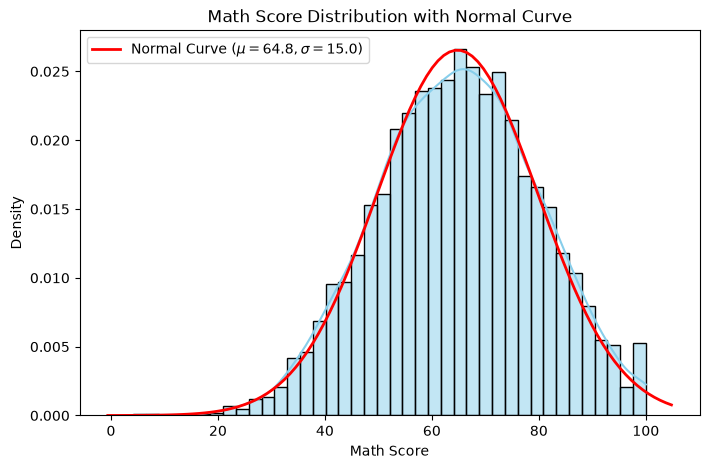

Science_Score - Skewness: -0.0242, Kurtosis: -0.2375


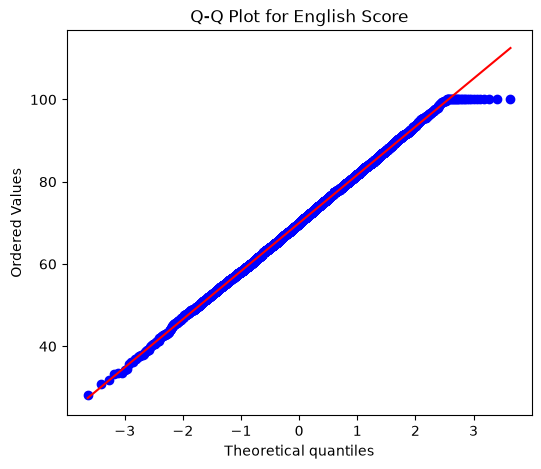

In [6]:
# ==========================================
# Step 3: Distribution & Visualization
# ==========================================
print("\n--- Step 3: Distribution & Visualization ---")

# 1. Histogram & Normal curve for Math_Score
plt.figure(figsize=(8, 5))
sns.histplot(df['Math_Score'], kde=True, stat="density", color="skyblue")

# Fit Normal distribution curve
mu, std = stats.norm.fit(df['Math_Score'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label=f'Normal Curve ($\mu={mu:.1f}, \sigma={std:.1f}$)')

plt.title("Math Score Distribution with Normal Curve")
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.legend()
plt.show()

# 2. Skewness & Kurtosis for Science_Score
science_skew = stats.skew(df['Science_Score'].dropna())
science_kurt = stats.kurtosis(df['Science_Score'].dropna())
print(f"Science_Score - Skewness: {science_skew:.4f}, Kurtosis: {science_kurt:.4f}")

# 3. Q-Q Plot for English_Score
plt.figure(figsize=(6, 5))
stats.probplot(df['English_Score'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot for English Score")
plt.show()




**Step 4: Linear Algebra Mini Task**
* Represent `Math_Score` and `Science_Score` of first 5 students as **vectors**.
* Perform:
  * **Dot product** of the two vectors.
  * **Norm 1 and Norm 2** of `Math_Score` vector.
  * Find **angle between the two vectors**.

In [7]:
# ==========================================
# Step 4: Linear Algebra Mini Task
# ==========================================
print("\n--- Step 4: Linear Algebra Mini Task ---")

# Represent Math_Score and Science_Score of first 5 students as vectors
math_vec = df['Math_Score'].head(5).to_numpy()
science_vec = df['Science_Score'].head(5).to_numpy()

print(f"Math Vector (first 5): {math_vec}")
print(f"Science Vector (first 5): {science_vec}")

# 1. Dot product
dot_product = np.dot(math_vec, science_vec)
print(f"Dot Product: {dot_product:.2f}")

# 2. Norm 1 and Norm 2 of Math_Score vector
norm_1_math = np.linalg.norm(math_vec, ord=1)
norm_2_math = np.linalg.norm(math_vec, ord=2)
print(f"Math Vector - L1 Norm: {norm_1_math:.2f}, L2 Norm: {norm_2_math:.2f}")

# 3. Angle between the two vectors (in degrees)
cos_theta = dot_product / (np.linalg.norm(math_vec) * np.linalg.norm(science_vec))
# Cosine value boundary handle કરવા માટે (clip)
cos_theta = np.clip(cos_theta, -1.0, 1.0)
angle_rad = np.arccos(cos_theta)
angle_deg = np.degrees(angle_rad)

print(f"Angle between vectors: {angle_rad:.4f} rad ({angle_deg:.2f} degrees)")


--- Step 4: Linear Algebra Mini Task ---
Math Vector (first 5): [78.4 72.1 72.3 59.6 69.8]
Science Vector (first 5): [43.3 73.3 66.  54.  48. ]
Dot Product: 20020.25
Math Vector - L1 Norm: 352.20, L2 Norm: 158.10
Angle between vectors: 0.2183 rad (12.51 degrees)
